# Active Learning with Gaussian Processes

This notebook demonstrates **ActiveLearner** from `pycse.sklearn` with scikit-learn's
`GaussianProcessRegressor` for classic Bayesian optimization.

We'll cover:
1. Finding the minimum of a 1D test function with Expected Improvement
2. Comparing acquisition functions (EI, UCB, LCB, PredictionVariance)
3. Batch strategies (greedy vs. penalized for diversity)
4. 2D optimization with a Branin-like function

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

from pycse.sklearn.active_learning import (
    ActiveLearner,
    ExpectedImprovement,
    LCB,
    PredictionVariance,
    UCB,
)

plt.style.use("default")
plt.rcParams["figure.dpi"] = 100

print("Imports successful")

Imports successful


## 1. Bayesian Optimization of a 1D Function

We'll minimize a wavy test function using Expected Improvement.
The ActiveLearner manages the suggest-evaluate-update loop.

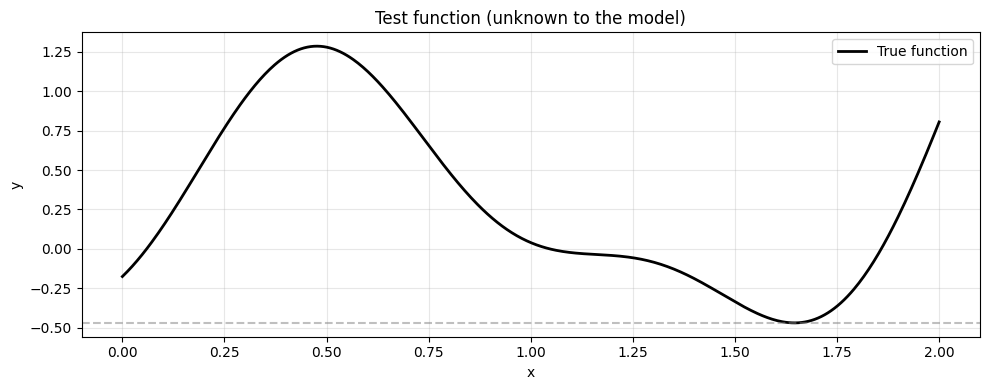

True minimum: y = -0.4687 at x = 1.6473


In [2]:
# Define our "experiment" (unknown to the model)
def oracle_1d(x):
    """Wavy function with a global minimum near x=0.75."""
    x = np.atleast_1d(x).ravel()
    return np.sin(3 * x) + 0.5 * (x - 0.5) ** 2 - 0.3 * np.cos(7 * x)


# Plot the true function
x_true = np.linspace(0, 2, 500)[:, None]
y_true = oracle_1d(x_true)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_true, y_true, "k-", lw=2, label="True function")
ax.axhline(y_true.min(), color="gray", ls="--", alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Test function (unknown to the model)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True minimum: y = {y_true.min():.4f} at x = {x_true[np.argmin(y_true), 0]:.4f}")

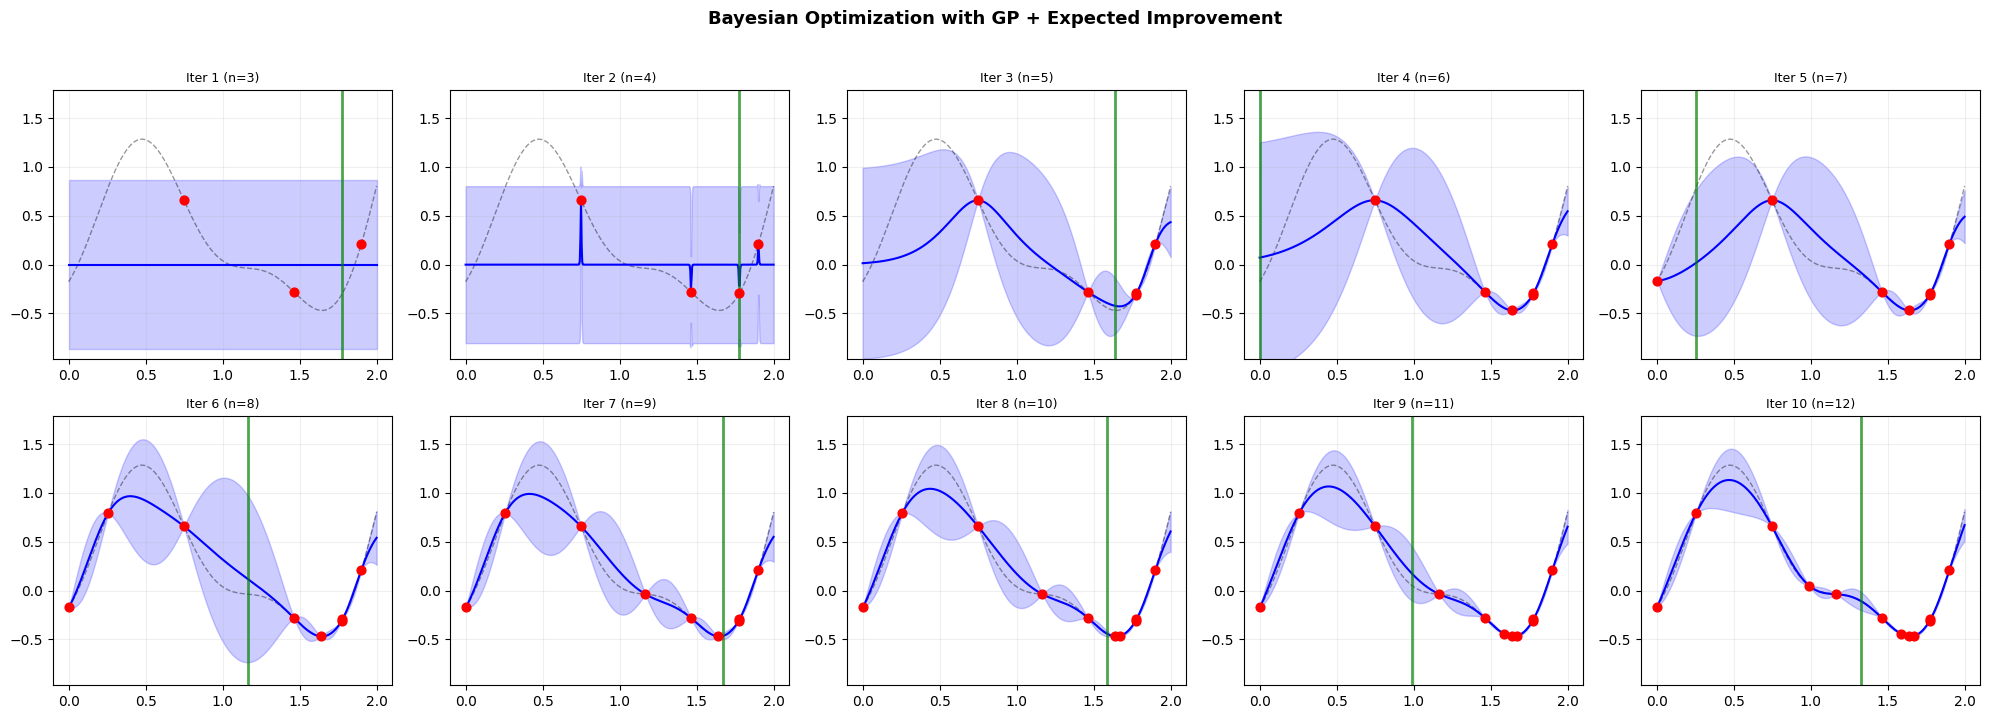


After 10 iterations:
  Best y found:  -0.4681
  Best x found:  1.6370
  True minimum:  -0.4687
  Total samples: 13


In [3]:
# Start with 3 random initial points
rng = np.random.RandomState(42)
X_init = rng.uniform(0, 2, size=(3, 1))
y_init = oracle_1d(X_init)

# Fit a Gaussian Process
kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=5)
gp.fit(X_init, y_init)

# Create the active learner
learner = ActiveLearner(
    model=gp,
    bounds=[(0, 2)],
    acquisition=ExpectedImprovement(minimize=True),
    n_candidates=500,
    random_state=42,
)
learner.X_train = X_init.copy()
learner.y_train = y_init.copy()

# Run 10 iterations, selecting 1 point each time
fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for i, ax in enumerate(axes.flat):
    # Plot current GP fit
    mu, std = gp.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4)
    ax.plot(x_true, mu, "b-", lw=1.5)
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.scatter(learner.X_train, learner.y_train, c="red", s=40, zorder=5)

    # Suggest the next point
    result = learner.suggest(n_points=1)
    ax.axvline(result.points[0, 0], color="green", ls="-", alpha=0.7, lw=2)
    ax.set_title(f"Iter {i + 1} (n={learner.n_observations})", fontsize=9)
    ax.set_ylim(y_true.min() - 0.5, y_true.max() + 0.5)
    ax.grid(True, alpha=0.2)

    # Evaluate oracle and update
    y_new = oracle_1d(result.points)
    learner.update(result.points, y_new)

plt.suptitle(
    "Bayesian Optimization with GP + Expected Improvement",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nAfter {learner.iteration} iterations:")
print(f"  Best y found:  {learner.best_y:.4f}")
print(f"  Best x found:  {learner.best_X[0]:.4f}")
print(f"  True minimum:  {y_true.min():.4f}")
print(f"  Total samples: {learner.n_observations}")

## 2. Comparing Acquisition Functions

Different acquisition functions trade off exploration and exploitation differently.
Let's compare four strategies on the same initial data.

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


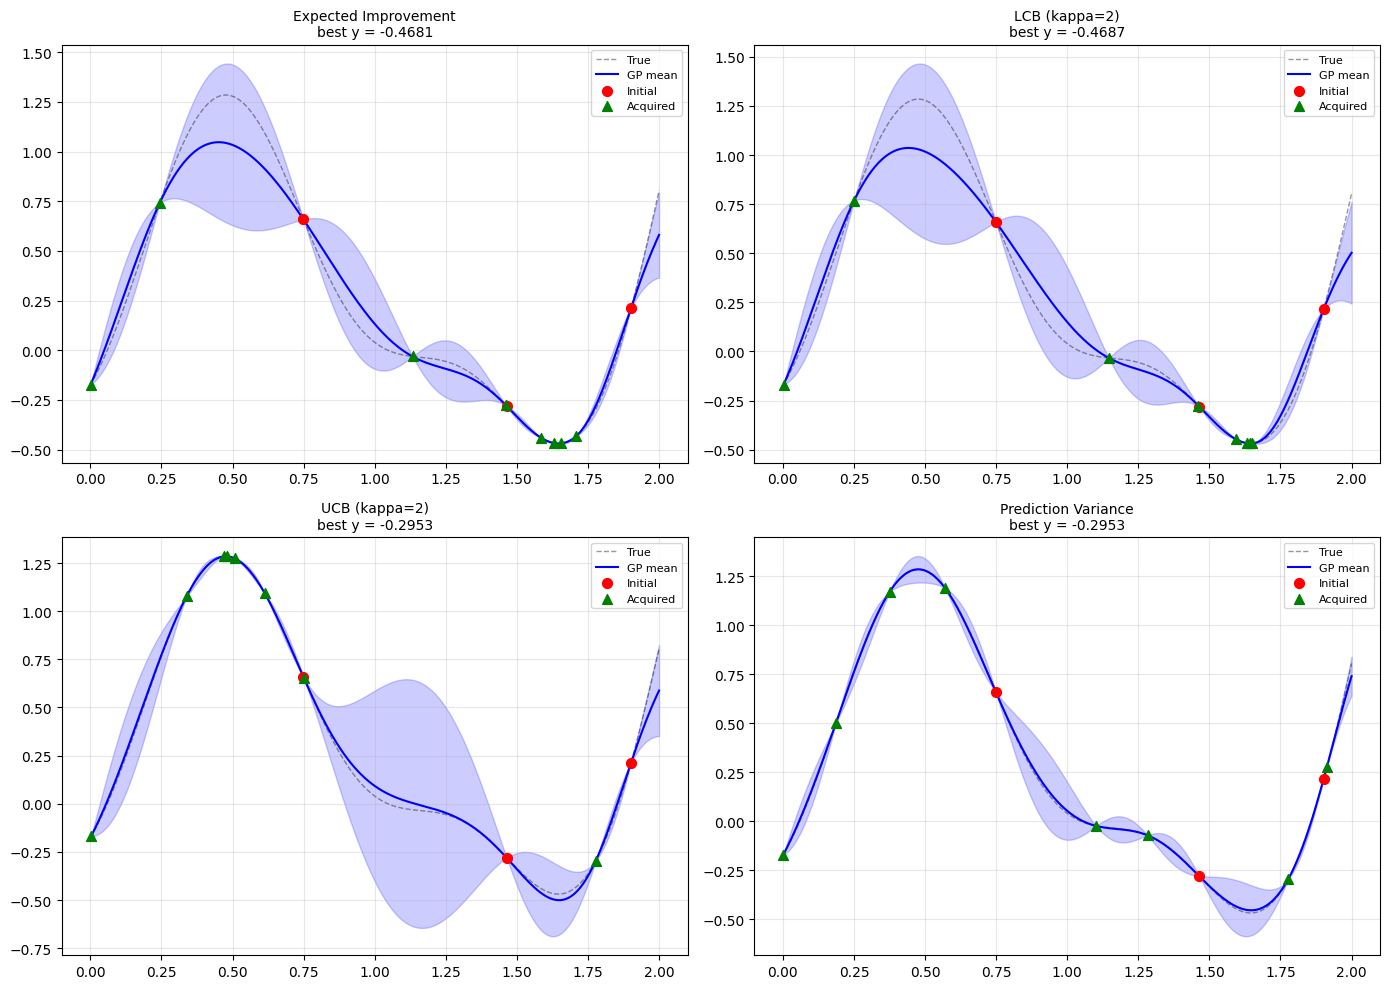

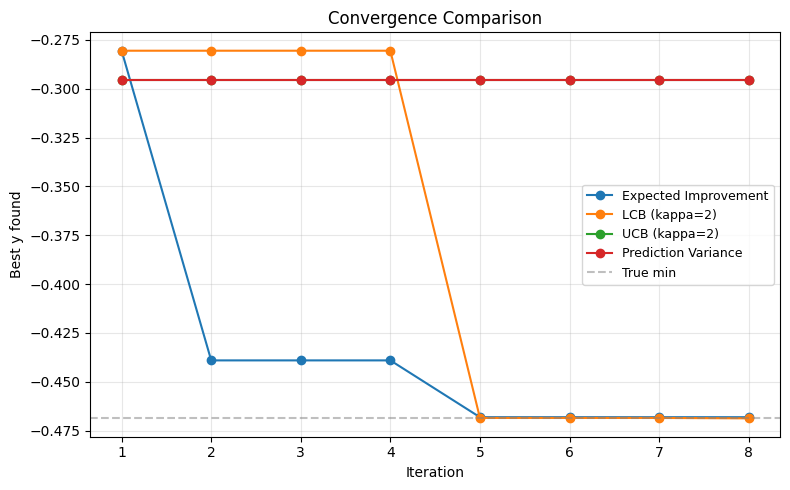

In [4]:
acquisitions = {
    "Expected Improvement": ExpectedImprovement(minimize=True),
    "LCB (kappa=2)": LCB(kappa=2.0),
    "UCB (kappa=2)": UCB(kappa=2.0),
    "Prediction Variance": PredictionVariance(),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
histories = {}

for ax, (name, acq) in zip(axes.flat, acquisitions.items()):
    # Fresh GP and learner for each
    gp = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5),
        alpha=1e-6,
        n_restarts_optimizer=5,
    )
    gp.fit(X_init, y_init)

    learner = ActiveLearner(
        model=gp,
        bounds=[(0, 2)],
        acquisition=acq,
        n_candidates=500,
        random_state=42,
    )
    learner.X_train = X_init.copy()
    learner.y_train = y_init.copy()

    # Run 8 iterations
    best_ys = []
    for _ in range(8):
        result = learner.suggest(n_points=1)
        y_new = oracle_1d(result.points)
        learner.update(result.points, y_new)
        best_ys.append(learner.best_y)

    histories[name] = best_ys

    # Plot final state
    mu, std = gp.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4, label="True")
    ax.plot(x_true, mu, "b-", lw=1.5, label="GP mean")
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.scatter(learner.X_train[:3], learner.y_train[:3], c="red", s=50, zorder=5, label="Initial")
    ax.scatter(
        learner.X_train[3:],
        learner.y_train[3:],
        c="green",
        s=50,
        marker="^",
        zorder=5,
        label="Acquired",
    )
    ax.set_title(f"{name}\nbest y = {learner.best_y:.4f}", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Convergence plot
fig, ax = plt.subplots(figsize=(8, 5))
for name, ys in histories.items():
    ax.plot(range(1, len(ys) + 1), ys, "o-", label=name)
ax.axhline(y_true.min(), color="gray", ls="--", alpha=0.5, label="True min")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best y found")
ax.set_title("Convergence Comparison")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Batch Strategies: Greedy vs. Penalized

When suggesting multiple points at once, **greedy** picks the top-k by score
(often clustered), while **penalized** adds a distance penalty to encourage
spatial diversity.

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


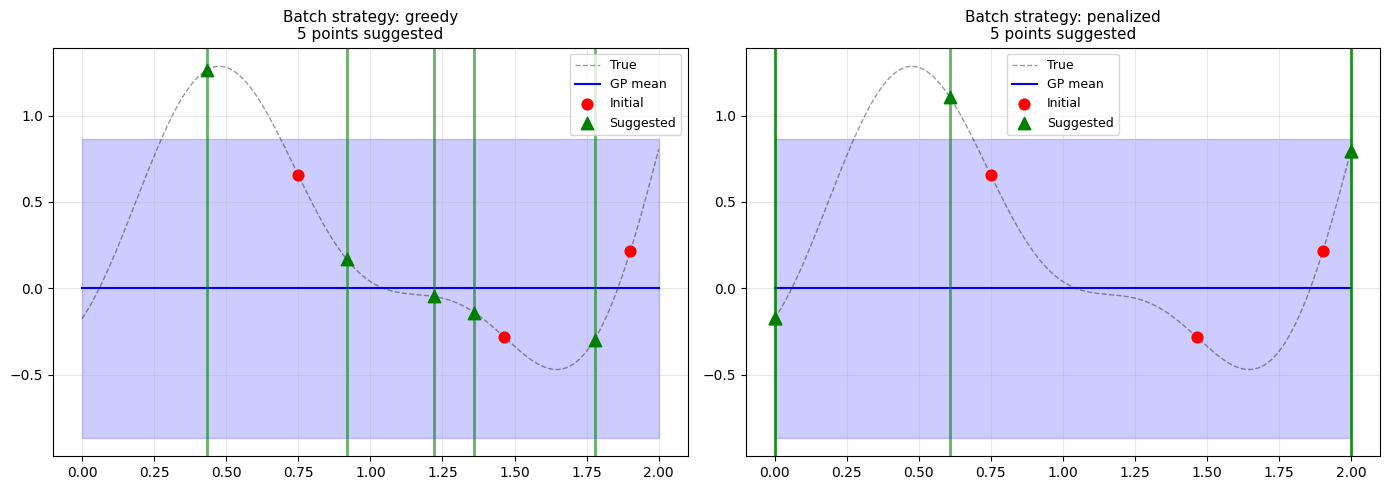

Greedy tends to cluster points near the best region.
Penalized spreads points out for better space coverage.


In [5]:
gp = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5),
    alpha=1e-6,
    n_restarts_optimizer=5,
)
gp.fit(X_init, y_init)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, strategy in zip(axes, ["greedy", "penalized"]):
    learner = ActiveLearner(
        model=gp,
        bounds=[(0, 2)],
        acquisition=LCB(kappa=2.0),
        n_candidates=500,
        random_state=42,
    )
    learner.X_train = X_init.copy()
    learner.y_train = y_init.copy()

    result = learner.suggest(n_points=5, batch_strategy=strategy)

    mu, std = gp.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4, label="True")
    ax.plot(x_true, mu, "b-", lw=1.5, label="GP mean")
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.scatter(X_init, y_init, c="red", s=60, zorder=5, label="Initial")

    for j, pt in enumerate(result.points):
        ax.axvline(pt[0], color="green", ls="-", alpha=0.6, lw=2)
    ax.scatter(
        result.points[:, 0],
        oracle_1d(result.points),
        c="green",
        s=80,
        marker="^",
        zorder=6,
        label="Suggested",
    )

    ax.set_title(f"Batch strategy: {strategy}\n5 points suggested", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Greedy tends to cluster points near the best region.")
print("Penalized spreads points out for better space coverage.")

## 4. 2D Optimization

Active learning scales to higher dimensions. Here we optimize a 2D
function with a GP model.

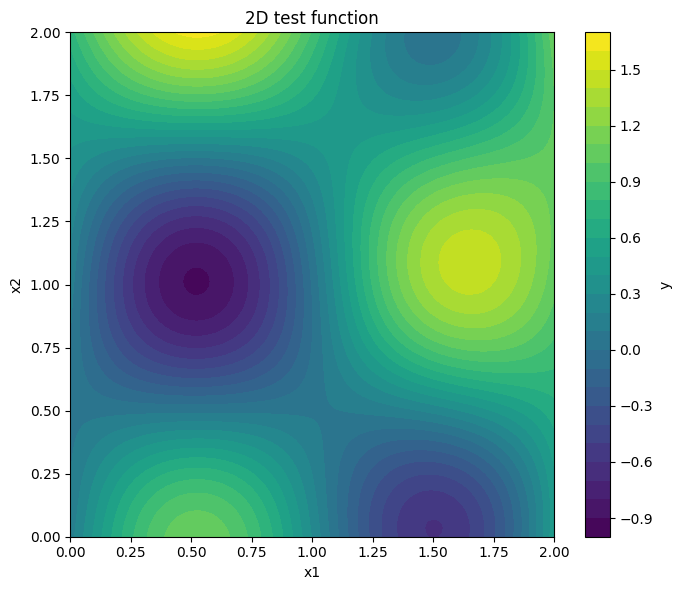

True minimum: -0.9155


In [6]:
def oracle_2d(X):
    """2D test function with multiple local minima."""
    X = np.atleast_2d(X)
    x1, x2 = X[:, 0], X[:, 1]
    return np.sin(3 * x1) * np.cos(3 * x2) + 0.3 * (x1 - 0.5) ** 2 + 0.3 * (x2 - 0.5) ** 2


# Visualize
xx = np.linspace(0, 2, 100)
X1, X2 = np.meshgrid(xx, xx)
Z = oracle_2d(np.column_stack([X1.ravel(), X2.ravel()])).reshape(X1.shape)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(X1, X2, Z, levels=30, cmap="viridis")
plt.colorbar(c, ax=ax, label="y")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("2D test function")
plt.tight_layout()
plt.show()

print(f"True minimum: {Z.min():.4f}")

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


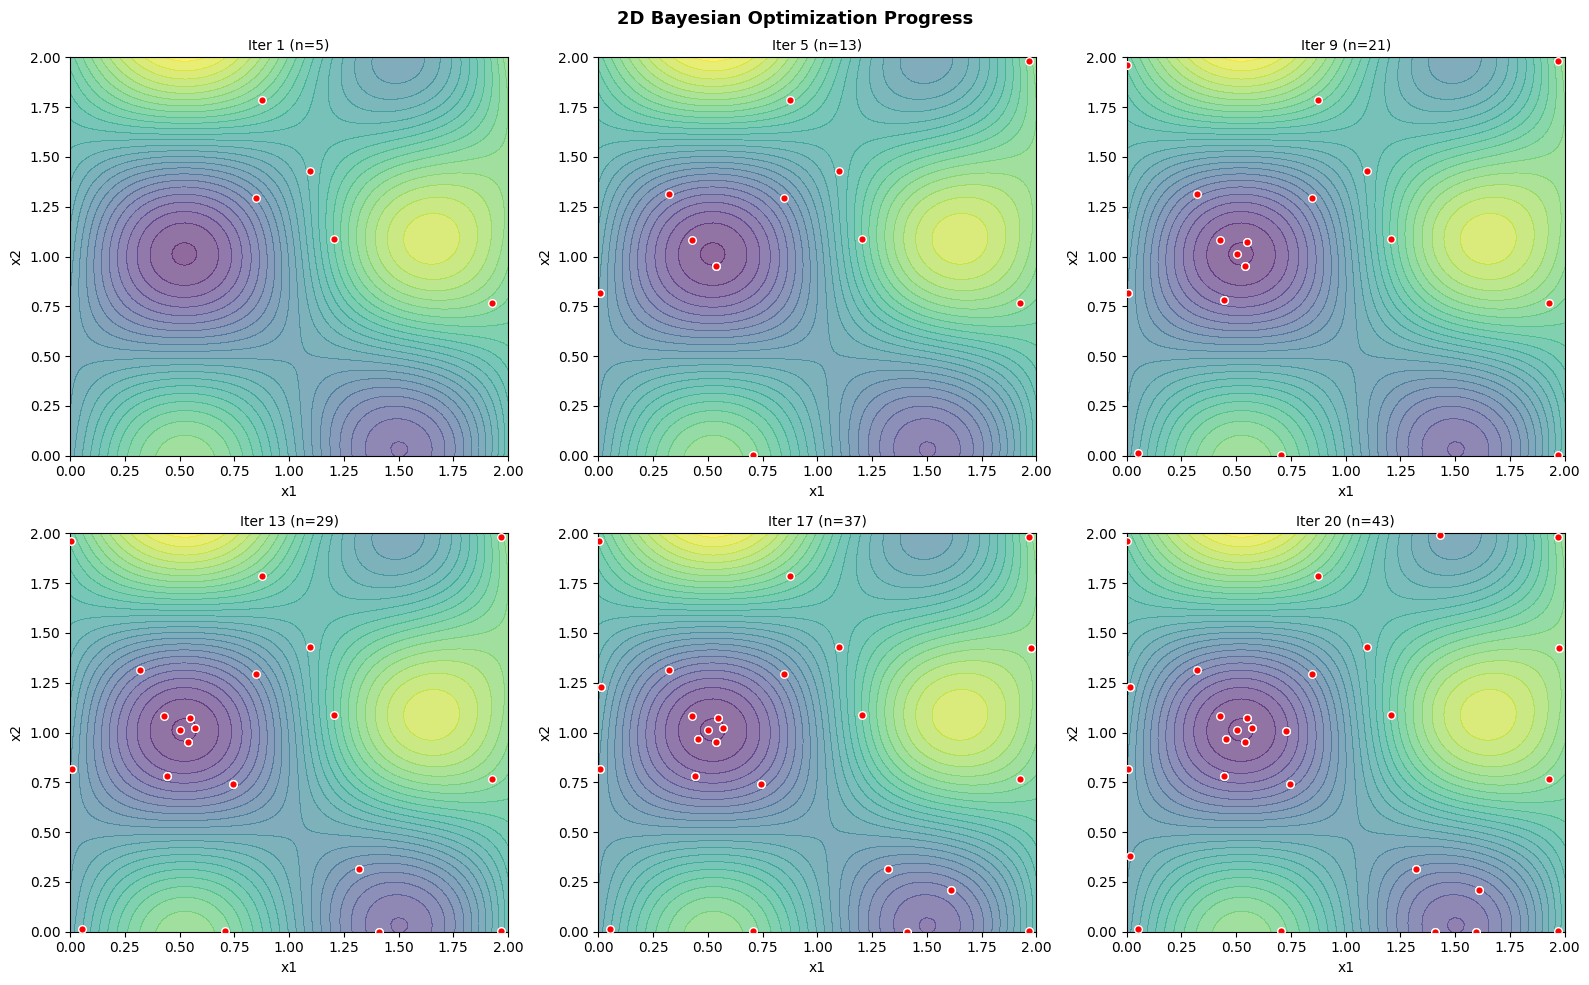

Best y found:  -0.9137
Best x found:  [0.50223065 1.01084432]
True minimum:  -0.9155
Total samples: 45


In [7]:
# Initial samples
rng = np.random.RandomState(0)
X_init_2d = rng.uniform(0, 2, size=(5, 2))
y_init_2d = oracle_2d(X_init_2d)

gp2d = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * Matern(length_scale=0.5, nu=2.5),
    alpha=1e-6,
    n_restarts_optimizer=5,
)
gp2d.fit(X_init_2d, y_init_2d)

learner2d = ActiveLearner(
    model=gp2d,
    bounds=[(0, 2), (0, 2)],
    acquisition=ExpectedImprovement(minimize=True),
    n_candidates=2000,
    random_state=42,
)
learner2d.X_train = X_init_2d.copy()
learner2d.y_train = y_init_2d.copy()

# Run 20 iterations, 2 points per batch
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_iters = [0, 4, 8, 12, 16, 19]
ax_idx = 0

for i in range(20):
    if i in plot_iters:
        ax = axes.flat[ax_idx]
        ax.contourf(X1, X2, Z, levels=30, cmap="viridis", alpha=0.6)
        ax.scatter(
            learner2d.X_train[:, 0],
            learner2d.X_train[:, 1],
            c="red",
            s=30,
            edgecolors="white",
            zorder=5,
        )
        ax.set_title(f"Iter {i + 1} (n={learner2d.n_observations})", fontsize=10)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax_idx += 1

    result = learner2d.suggest(n_points=2, batch_strategy="penalized")
    y_new = oracle_2d(result.points)
    learner2d.update(result.points, y_new)

plt.suptitle("2D Bayesian Optimization Progress", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Best y found:  {learner2d.best_y:.4f}")
print(f"Best x found:  {learner2d.best_X}")
print(f"True minimum:  {Z.min():.4f}")
print(f"Total samples: {learner2d.n_observations}")

## Summary

- **GaussianProcessRegressor** is the classic model for Bayesian optimization and works
  seamlessly with `ActiveLearner` since it natively supports `predict(X, return_std=True)`.
- **Expected Improvement** and **LCB** are good defaults for minimization.
- **Penalized batch strategy** gives better spatial diversity when selecting multiple points.
- The `suggest -> evaluate -> update` loop is the core pattern for active learning.